# Redes Neuronales en Análisis Marino-Costero

## Objetivos del Módulo
- Comprender la estructura de redes neuronales artificiales
- Entender perceptrones, capas y funciones de activación
- Aplicar redes neuronales a problemas de clasificación marina
- Implementar validación, early stopping y visualización de entrenamiento

## Contexto Marino-Costero
Las redes neuronales son poderosas para:
- Clasificación de especies marinas en imágenes submarinas
- Predicción de patrones oceanográficos
- Detección de anomalías en datos de sensores marinos
- Predicción de fenómenos del niño/oscilación ártica


## Teoría de Redes Neuronales

### Perceptrón
El perceptrón es la unidad básica de una red neuronal:

$$y = f(w_1 x_1 + w_2 x_2 + ... + w_n x_n + b)$$

Donde:
- **x_i**: características de entrada
- **w_i**: pesos
- **b**: sesgo (bias)
- **f**: función de activación

### Capas Neurales
Una red neuronal se compone de:
1. **Capa de entrada**: Recibe características
2. **Capas ocultas**: Aprenden representaciones intermedias
3. **Capa de salida**: Produce predicciones

### Funciones de Activación

| Función | Ecuación | Rango | Uso |
|---------|----------|-------|-----|
| **ReLU** | f(x) = max(0, x) | [0, ∞) | Capas ocultas (default) |
| **Sigmoid** | f(x) = 1/(1+e^(-x)) | (0, 1) | Clasificación binaria |
| **Softmax** | f(x_i) = e^(x_i)/Σe^(x_j) | (0, 1) suma=1 | Clasificación multiclase |
| **Tanh** | f(x) = (e^x - e^(-x))/(e^x + e^(-x)) | (-1, 1) | Capas ocultas |

### Backpropagation (Retropropagación)
El algoritmo de entrenamiento fundamental:

1. **Forward Pass**: Computar predicciones
2. **Calcular Error**: Comparar con valores reales
3. **Backward Pass**: Computar gradientes del error respecto a cada peso
4. **Actualizar Pesos**: Mover en dirección opuesta al gradiente

$$w_{nuevo} = w_{viejo} - \alpha \cdot \frac{\partial E}{\partial w}$$

donde α es la tasa de aprendizaje (learning rate).


## Selección de Arquitectura de Red

### Consideraciones Clave

1. **Número de capas ocultas**: 
   - 1 capa: Suficiente para problemas no-lineales simples
   - 2+ capas: Necesarias para patrones complejos
   - Red profunda: > 5 capas (requiere regularización cuidadosa)

2. **Número de neuronas por capa**:
   - Regla heurística: Entre el tamaño de entrada y salida
   - Común: Disminuir exponencialmente (e.g., 128 → 64 → 32)

3. **Función de activación**:
   - ReLU: Default para capas ocultas (evita vanishing gradient)
   - Sigmoid/Softmax: Para capa de salida

4. **Regularización**:
   - Dropout: Desactiva neuronas aleatoriamente durante entrenamiento
   - L1/L2: Penaliza pesos grandes
   - Early Stopping: Detiene cuando validation loss aumenta

### Arquitectura para Clasificación Marina
```
Entrada (características) → 128 neuronas (ReLU) 
                         → 64 neuronas (ReLU) 
                         → 32 neuronas (ReLU) 
                         → Salida (Softmax)
```

Esta arquitectura es apropiadad para problemas de clasificación de complejidad media.


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris, fetch_openml
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

# Load Iris Dataset for learning purposes
print("=" * 60)
print("Ejemplo 1: Dataset Iris (para propósitos educativos)")
print("=" * 60)

iris = load_iris()
X_iris = iris.data
y_iris_labels = iris.target
target_names = iris.target_names

print(f"Iris data shape: {X_iris.shape}")
print(f"Classes: {target_names}")
print(f"Data sample:\n{X_iris[:3]}")

# Normalize features
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

# Split data with random_state for reproducibility
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris_scaled, y_iris_labels,
    test_size=0.2,
    random_state=42,
    stratify=y_iris_labels
)

print(f"\nTraining set size: {X_train_iris.shape[0]}")
print(f"Test set size: {X_test_iris.shape[0]}")

# Build a simple neural network for Iris classification
model_iris = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(4,), name='input_layer'),
    layers.Dense(32, activation='relu', name='hidden_1'),
    layers.Dense(16, activation='relu', name='hidden_2'),
    layers.Dense(3, activation='softmax', name='output_layer')
])

print("\n" + "=" * 60)
print("Arquitectura del Modelo Iris")
print("=" * 60)
model_iris.summary()

# Compile model
model_iris.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train with early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_iris = model_iris.fit(
    X_train_iris, y_train_iris,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0
)

# Evaluate on test set
test_loss_iris, test_accuracy_iris = model_iris.evaluate(X_test_iris, y_test_iris, verbose=0)
print(f"\nTest Accuracy: {test_accuracy_iris:.4f}")
print(f"Test Loss: {test_loss_iris:.4f}")


(1000, 2)


ValueError: ignored

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history_iris.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history_iris.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy (Iris Dataset)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history_iris.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history_iris.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss (Iris Dataset)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEntrenamiento completado en {len(history_iris.history['loss'])} épocas")


In [ ]:
# Confusion Matrix for Iris
y_pred_iris = model_iris.predict(X_test_iris, verbose=0).argmax(axis=1)
cm_iris = confusion_matrix(y_test_iris, y_pred_iris)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_iris, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Confusion Matrix - Iris Classification', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nClassification Report (Iris):")
print(classification_report(y_test_iris, y_pred_iris, target_names=target_names))


In [ ]:
print("\n" + "=" * 60)
print("Ejemplo 2: Fashion MNIST - Clasificación de Ropa")
print("=" * 60)

# Load Fashion MNIST
(X_train_fashion, y_train_fashion), (X_test_fashion, y_test_fashion) = keras.datasets.fashion_mnist.load_data()

# Class names in Spanish (or English for consistency)
fashion_classes = [
    "Camiseta",      # T-shirt
    "Pantalón",      # Trouser
    "Suéter",        # Pullover
    "Vestido",       # Dress
    "Abrigo",        # Coat
    "Sandalia",      # Sandal
    "Camisa",        # Shirt
    "Zapatilla",     # Sneaker
    "Bolsa",         # Bag
    "Bota"           # Ankle Boot
]

print(f"Fashion MNIST data shape: {X_train_fashion.shape}")
print(f"Classes: {fashion_classes}")

# Normalize pixel values to [0, 1]
X_train_fashion_normalized = X_train_fashion.astype('float32') / 255.0
X_test_fashion_normalized = X_test_fashion.astype('float32') / 255.0

# Flatten images
X_train_fashion_flat = X_train_fashion_normalized.reshape(-1, 28*28)
X_test_fashion_flat = X_test_fashion_normalized.reshape(-1, 28*28)

print(f"Flattened training data shape: {X_train_fashion_flat.shape}")

# Build neural network for Fashion MNIST
model_fashion = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,), name='input_layer'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu', name='hidden_1'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu', name='hidden_2'),
    layers.Dense(32, activation='relu', name='hidden_3'),
    layers.Dense(10, activation='softmax', name='output_layer')
])

print("\n" + "=" * 60)
print("Arquitectura del Modelo Fashion MNIST")
print("=" * 60)
model_fashion.summary()

# Compile
model_fashion.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train with early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_fashion = model_fashion.fit(
    X_train_fashion_flat, y_train_fashion,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0
)

# Evaluate
test_loss_fashion, test_accuracy_fashion = model_fashion.evaluate(
    X_test_fashion_flat, y_test_fashion,
    verbose=0
)
print(f"\nFashion MNIST Test Accuracy: {test_accuracy_fashion:.4f}")
print(f"Fashion MNIST Test Loss: {test_loss_fashion:.4f}")


In [ ]:
# Plot Fashion MNIST training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_fashion.history['accuracy'], label='Training Accuracy')
axes[0].plot(history_fashion.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Fashion MNIST - Model Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_fashion.history['loss'], label='Training Loss')
axes[1].plot(history_fashion.history['val_loss'], label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Fashion MNIST - Model Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Confusion Matrix for Fashion MNIST
y_pred_fashion = model_fashion.predict(X_test_fashion_flat, verbose=0).argmax(axis=1)

# Sample subset for better visualization
sample_size = 100
sample_indices = np.random.choice(len(y_test_fashion), sample_size, replace=False)
cm_fashion = confusion_matrix(
    y_test_fashion[sample_indices],
    y_pred_fashion[sample_indices]
)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_fashion, annot=True, fmt='d', cmap='Greens',
            xticklabels=fashion_classes,
            yticklabels=fashion_classes)
plt.title('Confusion Matrix - Fashion MNIST Classification (Sample)', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Full accuracy
print(f"\nFashion MNIST Full Test Set Accuracy: {accuracy_score(y_test_fashion, y_pred_fashion):.4f}")

# Sample classification report
print("\nClassification Report (sample):")
print(classification_report(
    y_test_fashion[sample_indices],
    y_pred_fashion[sample_indices],
    target_names=fashion_classes
))


4422102/4422102 [==============================] - 0s 0us/step
Epoch 1/10
1875/1875 [==============================] - 14s 7ms/step - loss: 0.4986 - accuracy: 0.8260 - val_loss: 0.4274 - val_accuracy: 0.8493
Epoch 2/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.3789 - accuracy: 0.8641 - val_loss: 0.4247 - val_accuracy: 0.8466
Epoch 3/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.3405 - accuracy: 0.8765 - val_loss: 0.3542 - val_accuracy: 0.8679
Epoch 4/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.3137 - accuracy: 0.8860 - val_loss: 0.3757 - val_accuracy: 0.8647
Epoch 5/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.2961 - accuracy: 0.8897 - val_loss: 0.3629 - val_accuracy: 0.8722
Epoch 6/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.2798 - accuracy: 0.8963 - val_loss: 0.3462 - val_accuracy: 0.8788
Epoch 7/10
1875/1875 [==============================] - 9s 5ms/step - 

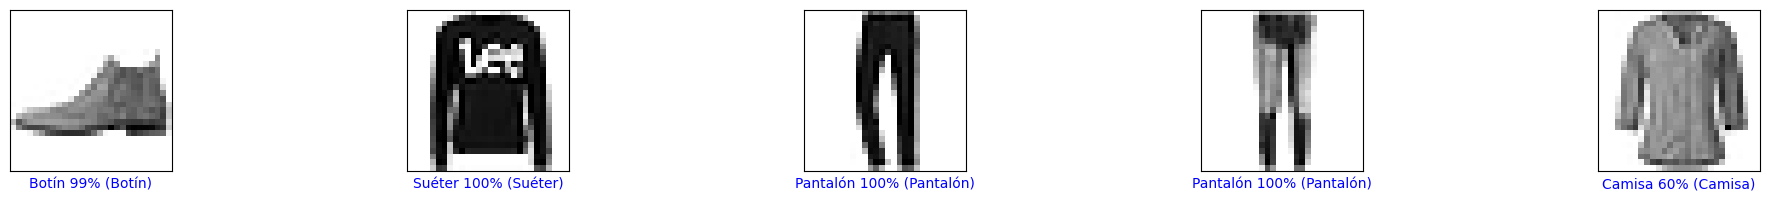

In [ ]:
# Importar librerías necesarias
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Cargar el conjunto de datos Fashion MNIST
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

# Normalizar los valores de los píxeles a un rango de 0 a 1
train_images = train_images / 255.0
test_images = test_images / 255.0

# Definir las etiquetas de las clases
class_names = ['Camiseta', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo', 'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

# Construir el modelo
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10)
])

# Compilar el modelo
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))

# Evaluar el modelo
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print('\nTest accuracy:', test_acc)

# Crear un modelo con función de activación softmax para convertir logits a probabilidades
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])

# Predecir algunas imágenes
predictions = probability_model.predict(test_images)

# Función para visualizar las predicciones
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'
    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                         100*np.max(predictions_array),
                                         class_names[true_label]),
                                         color=color)

# Visualizar las predicciones para las primeras 5 imágenes
num_rows = 1
num_cols = 5
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions[i], test_labels, test_images)
plt.tight_layout()
plt.show()


## Ejercicios para el Estudiante

### Ejercicio 1: Experimentar con Arquitecturas
Modifica la arquitectura de la red neuronal para Iris:
- Intenta con diferentes números de capas (1, 2, 3, 4)
- Intenta con diferentes números de neuronas (32, 64, 128, 256)
- ¿Cuál arquitectura da mejor balance entre accuracy y velocidad de entrenamiento?

```python
# Template
model = models.Sequential([
    layers.Dense(..., activation='relu', input_shape=(4,)),
    # Añade más capas aquí
    layers.Dense(3, activation='softmax')
])
```

### Ejercicio 2: Impacto de Dropout y Regularización
Compara modelos con y sin:
- Dropout (0.2, 0.5)
- L1/L2 regularization

¿Cómo afecta cada técnica al overfitting?

```python
layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))
layers.Dropout(0.3)
```

### Ejercicio 3: Análisis de Predicciones Erróneas
Para Fashion MNIST:
- Identifica las muestras que el modelo predice incorrectamente
- Visualiza algunas de estas imágenes
- ¿Por qué crees que el modelo se equivocó?

```python
# Encuentra índices de predicciones incorrectas
wrong_indices = np.where(y_pred_fashion != y_test_fashion)[0]

# Visualiza algunas
for idx in wrong_indices[:5]:
    img = X_test_fashion[idx].reshape(28, 28)
    print(f"True: {fashion_classes[y_test_fashion[idx]]}, Predicted: {fashion_classes[y_pred_fashion[idx]]}")
    plt.imshow(img, cmap='gray')
    plt.show()
```
